<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import boxcox, yeojohnson


## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [2]:
# Your code here
df=pd.read_csv('./data/College.csv')

In [3]:
df.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [4]:
df.rename(columns={'Unnamed: 0':'name'},inplace=True)

#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [5]:
# Your code here
df.shape


(777, 19)

In [6]:
df.dtypes

name               str
Private            str
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD                str
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object

In [7]:
df.isnull().sum()

name           0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [8]:
# Your code here

df['PhD'] = pd.to_numeric(df['PhD'], errors='coerce')
df.loc[df['PhD'] > 100, 'PhD'] = np.nan
df['PhD'] = df['PhD'].fillna(df['PhD'].median())


#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [9]:
df['Grad.Rate'] = pd.to_numeric(df['Grad.Rate'], errors='coerce')
df.loc[df['PhD'] > 100, 'PhD'] = np.nan
df['Grad.Rate'] = df['Grad.Rate'].fillna(df['Grad.Rate'].median())


## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [10]:
df.columns

Index(['name', 'Private', 'Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc',
       'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board', 'Books',
       'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend',
       'Grad.Rate'],
      dtype='str')

In [11]:
%%writefile myutils.py
import numpy as np
import pandas as pd

def skew_calc(df):
    results = []
    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        series = df[col].dropna()

        if series.empty or series.nunique() <= 2:
            continue

        skewness = series.skew()

        if abs(skewness) <= 0.5:
            degree = "Approximately Symmetric"
        elif abs(skewness) <= 1:
            degree = "Moderately Skewed"
        else:
            degree = "Highly Skewed"

        if skewness >= 0:
            direction = "Positive"
        else:
            direction = "Negative"

        if abs(skewness) <= 0.5:
            recommendation = "None needed"
        else:
            min_val = series.min()
            if min_val > 0:
                recommendation = "Box-Cox or Yeo-Johnson"
            elif min_val == 0:
                recommendation = "log(x+1) or Yeo-Johnson"
            else:
                recommendation = "Yeo-Johnson"

        results.append({
            "Feature": col,
            "Skewness": round(skewness, 6),
            "Degree": degree,
            "Direction": direction,
            "Recommended Transformation": recommendation
        })

    return pd.DataFrame(results)

Writing myutils.py


In [12]:
# Now import the function from myutils

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Approximately Symmetric,Positive,None needed
5,F.Undergrad,2.610458,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Positive,Box-Cox or Yeo-Johnson
8,Room.Board,0.477356,Approximately Symmetric,Positive,None needed
9,Books,3.485025,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


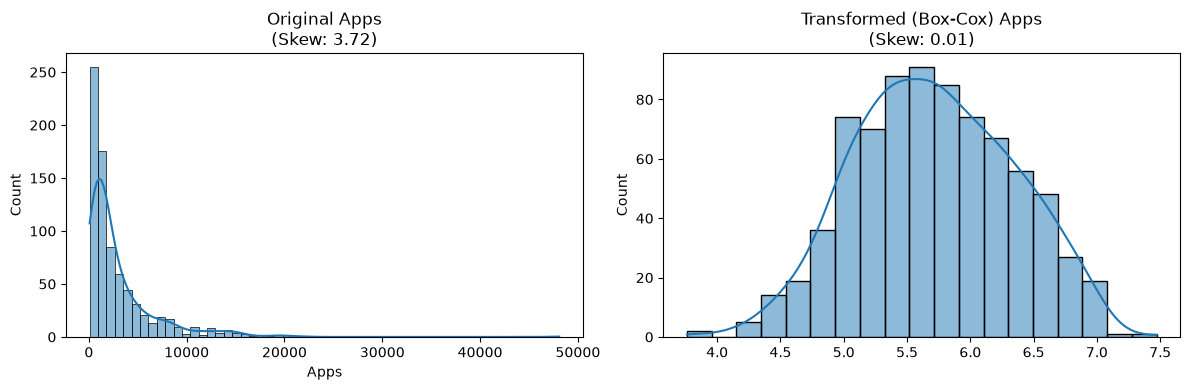

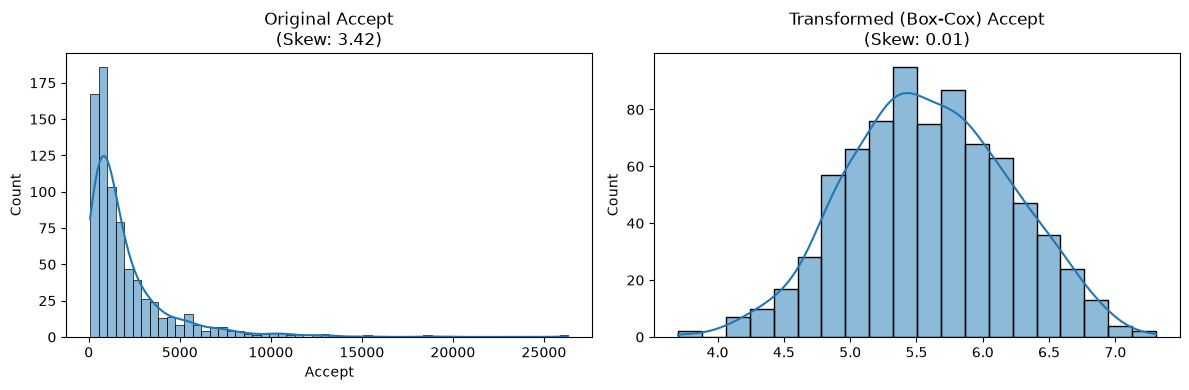

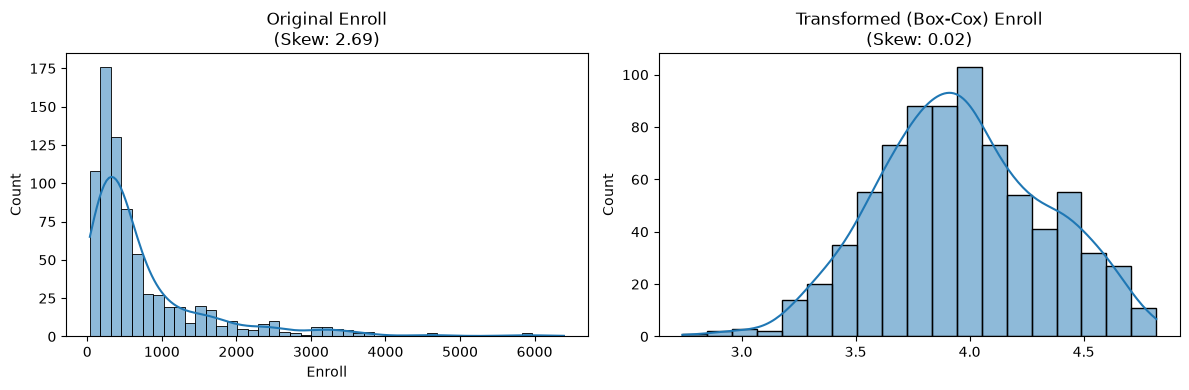

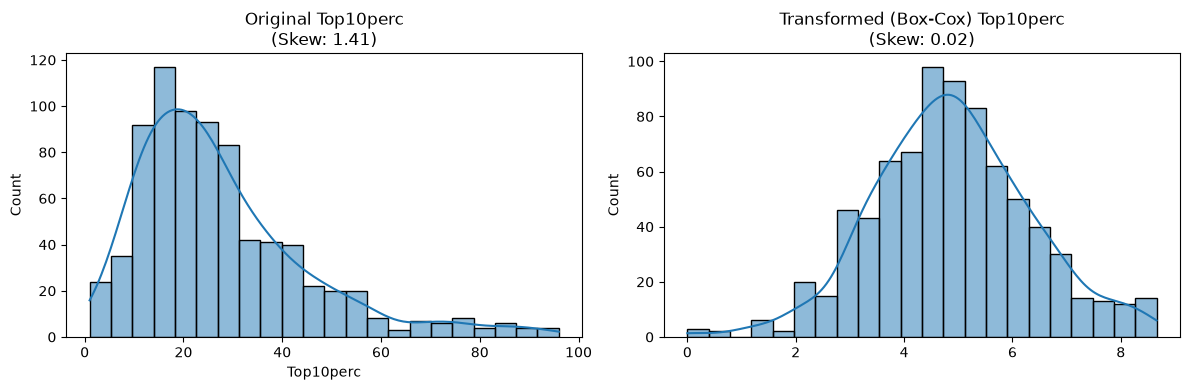

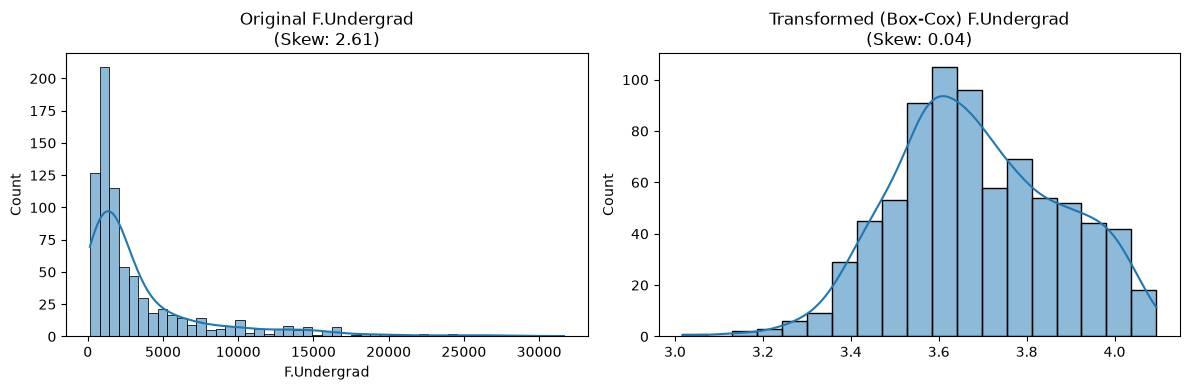

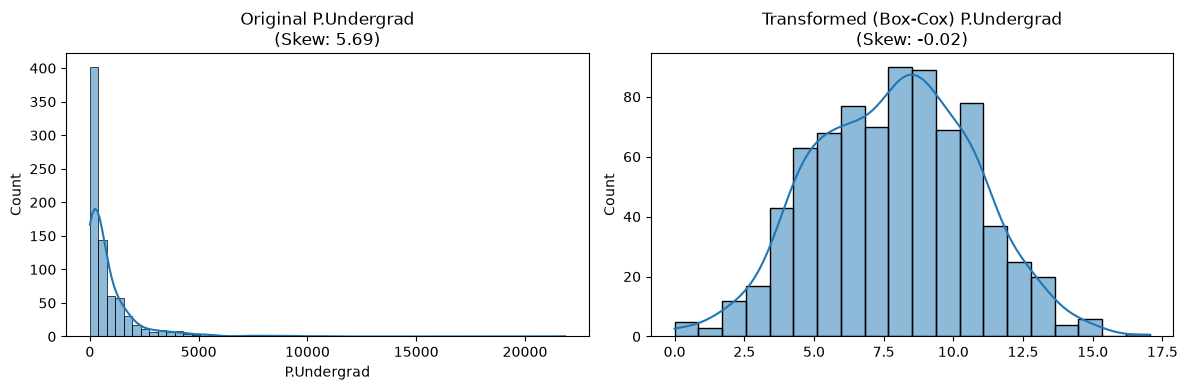

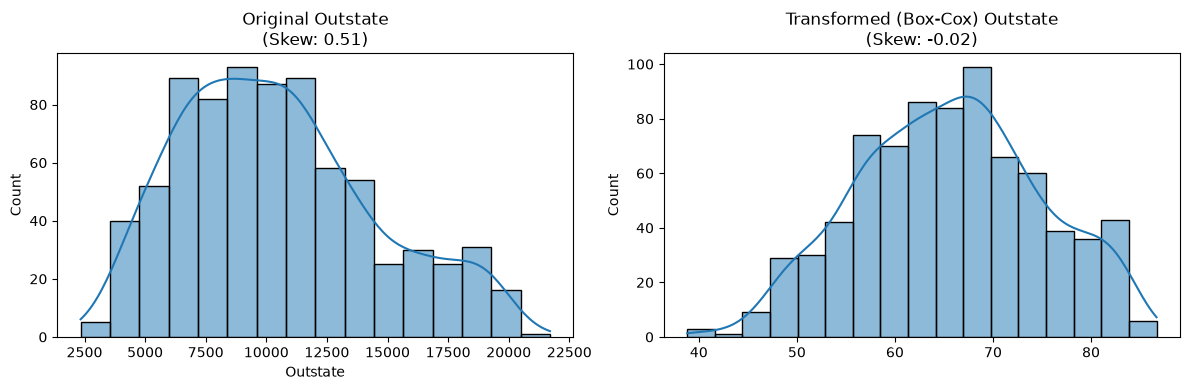

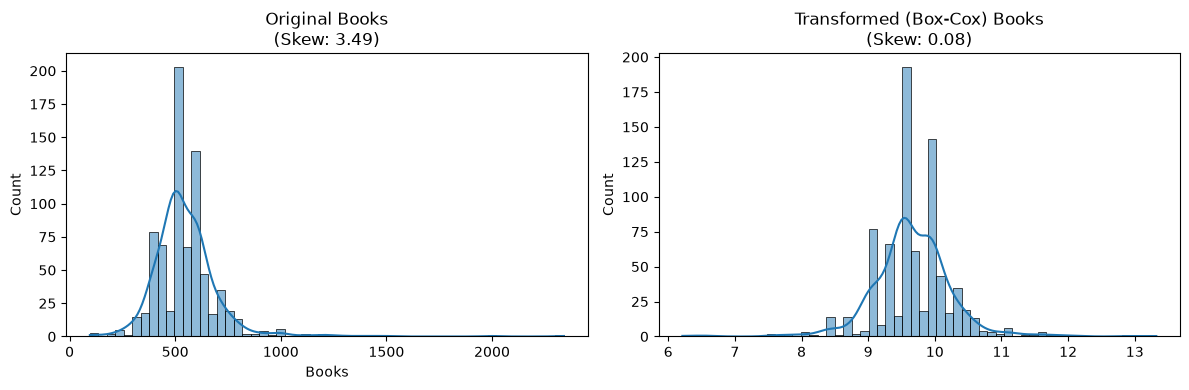

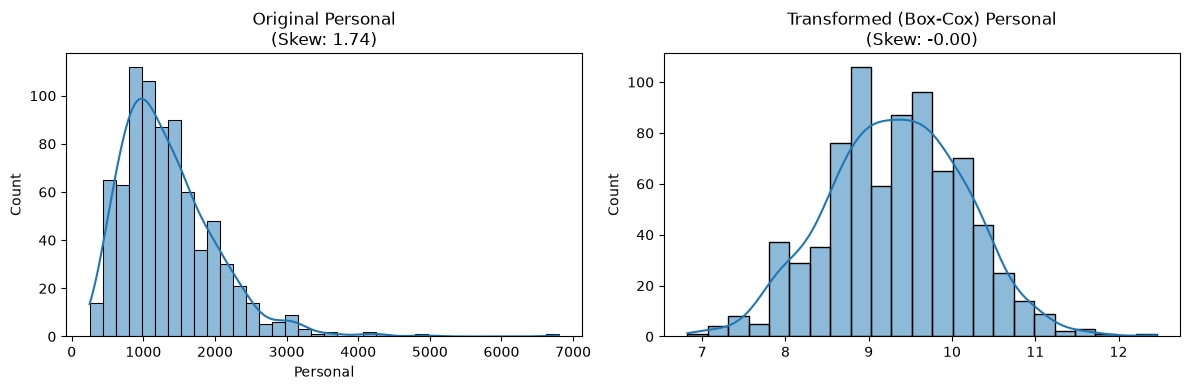

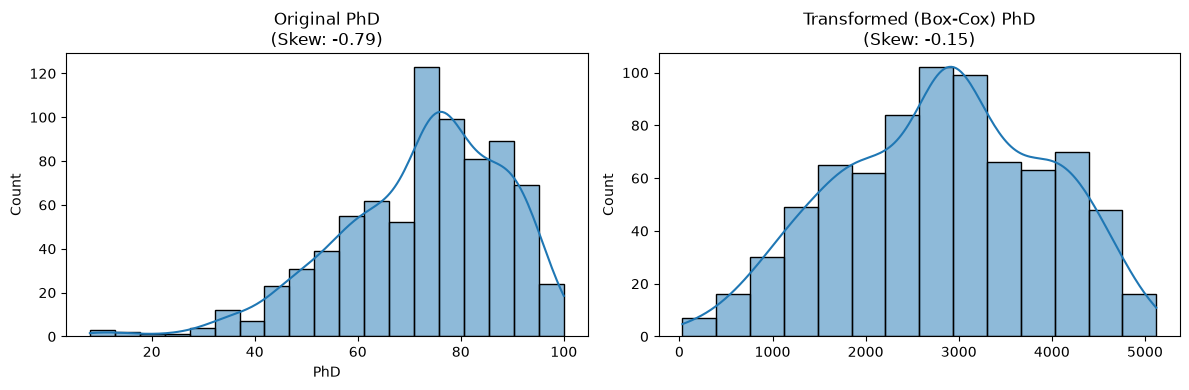

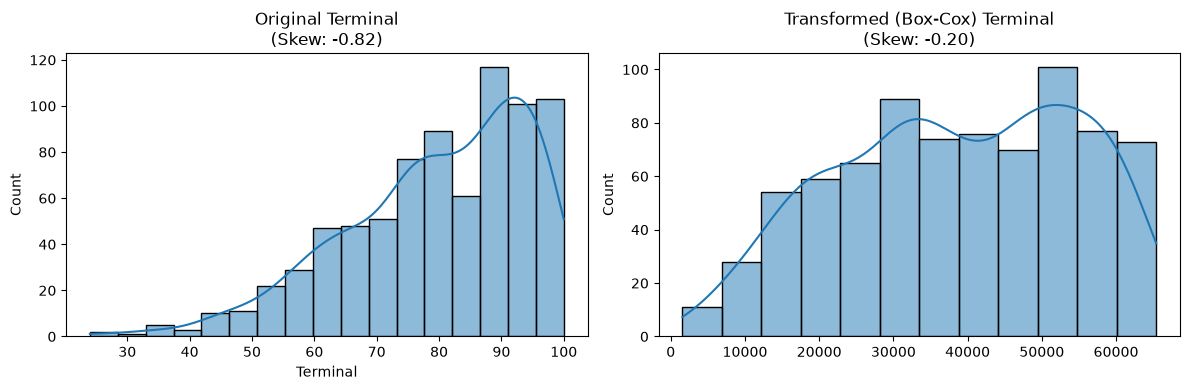

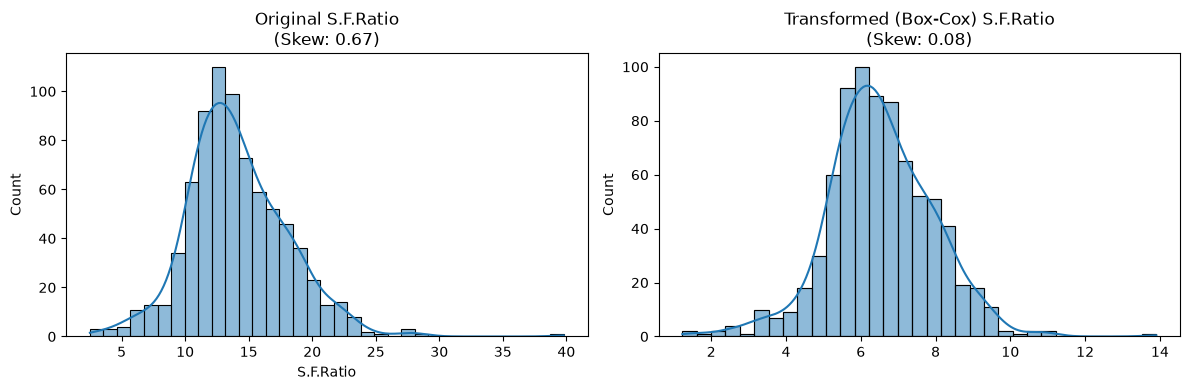

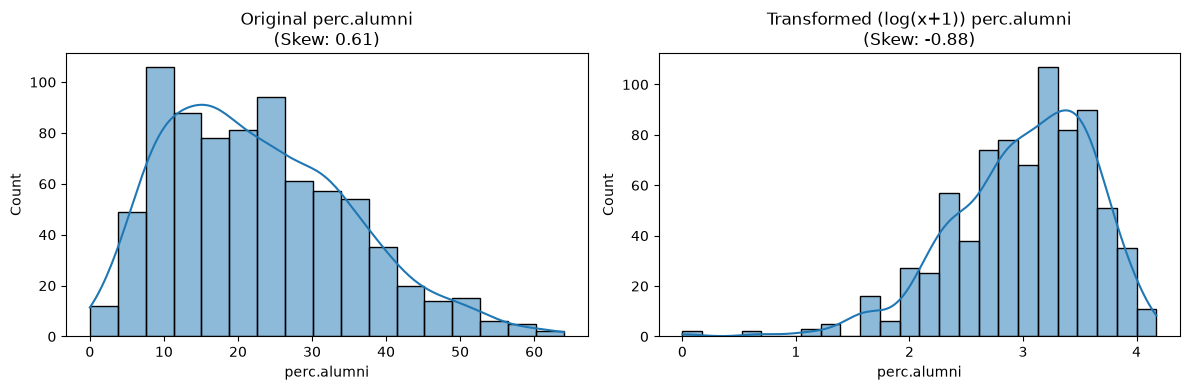

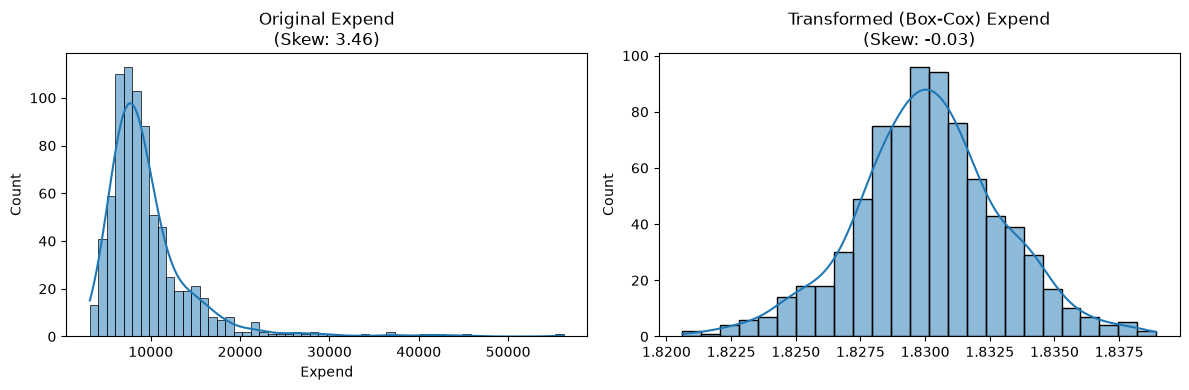

In [13]:
import sys
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import boxcox, yeojohnson

sys.path.append(".")

import myutils
importlib.reload(myutils)
from myutils import skew_calc


def plot_transformations(df, skew_table):
    skewed_features = skew_table[
        skew_table["Recommended Transformation"] != "None needed"
    ]

    for _, row in skewed_features.iterrows():
        col = row["Feature"]
        rec = row["Recommended Transformation"]
        original_data = df[col].dropna()
        orig_skew = original_data.skew()

        if "log(x+1)" in rec or "log" in rec:
            transformed_data = np.log1p(original_data)
            trans_label = "log(x+1)"
        elif "Box-Cox" in rec and original_data.min() > 0:
            transformed_data, _ = boxcox(original_data)
            trans_label = "Box-Cox"
        else:
            transformed_data, _ = yeojohnson(original_data)
            trans_label = "Yeo-Johnson"

        trans_skew = pd.Series(transformed_data).skew()

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(original_data, kde=True, ax=axes[0])
        axes[0].set_title(f"Original {col}\n(Skew: {orig_skew:.2f})")

        sns.histplot(transformed_data, kde=True, ax=axes[1])
        axes[1].set_title(
            f"Transformed ({trans_label}) {col}\n(Skew: {trans_skew:.2f})"
        )

        plt.tight_layout()
        plt.show()


skew_results = skew_calc(df)
display(skew_results)
plot_transformations(df, skew_results)

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Approximately Symmetric,Positive,None needed
5,F.Undergrad,2.610458,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Positive,Box-Cox or Yeo-Johnson
8,Room.Board,0.477356,Approximately Symmetric,Positive,None needed
9,Books,3.485025,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


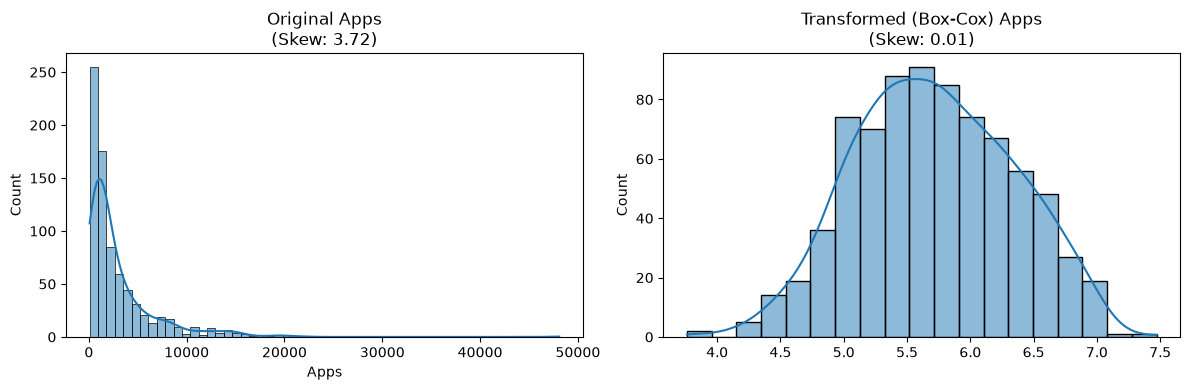

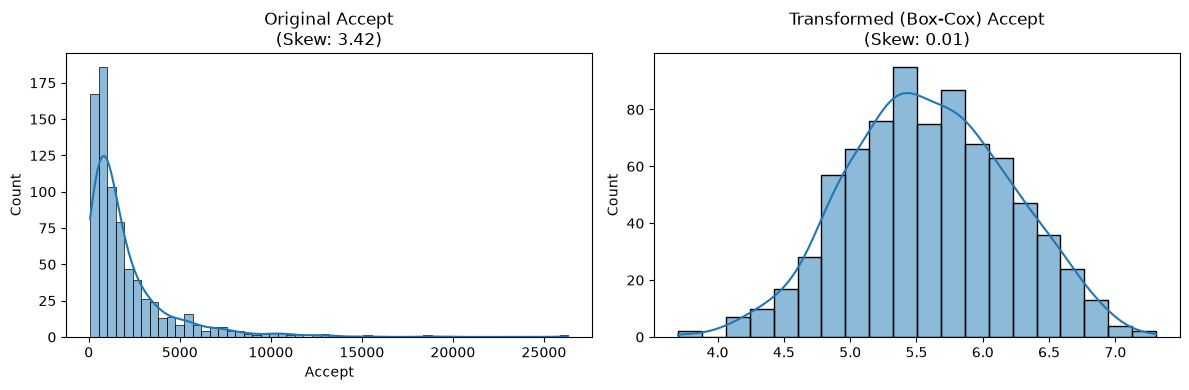

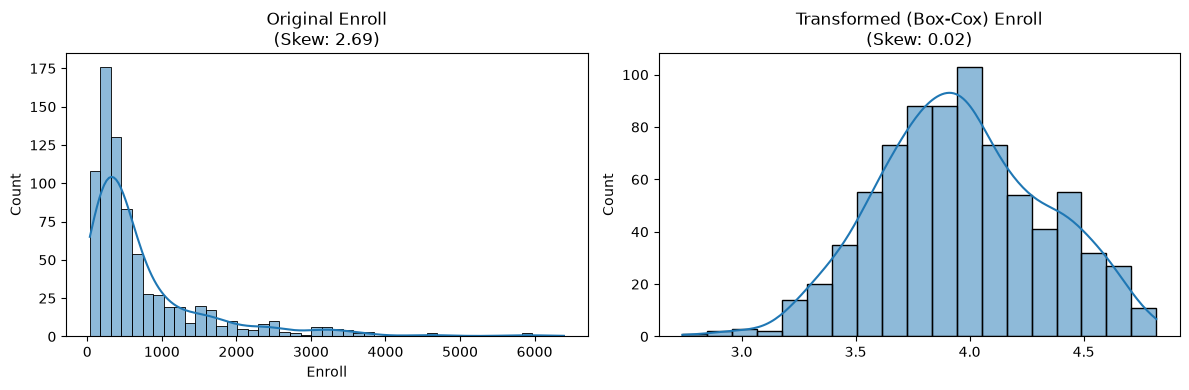

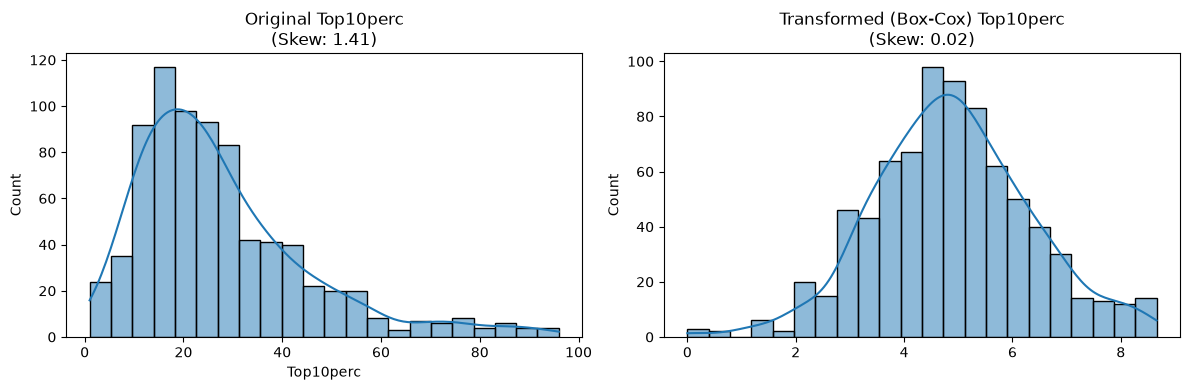

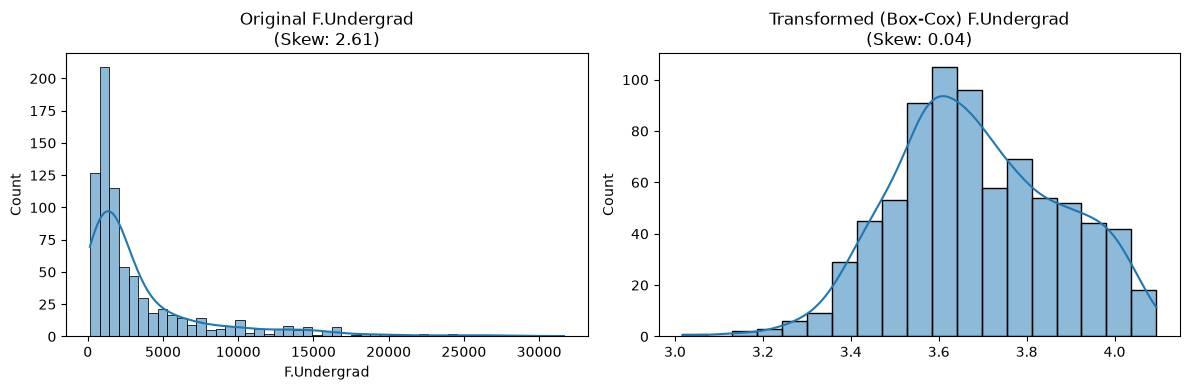

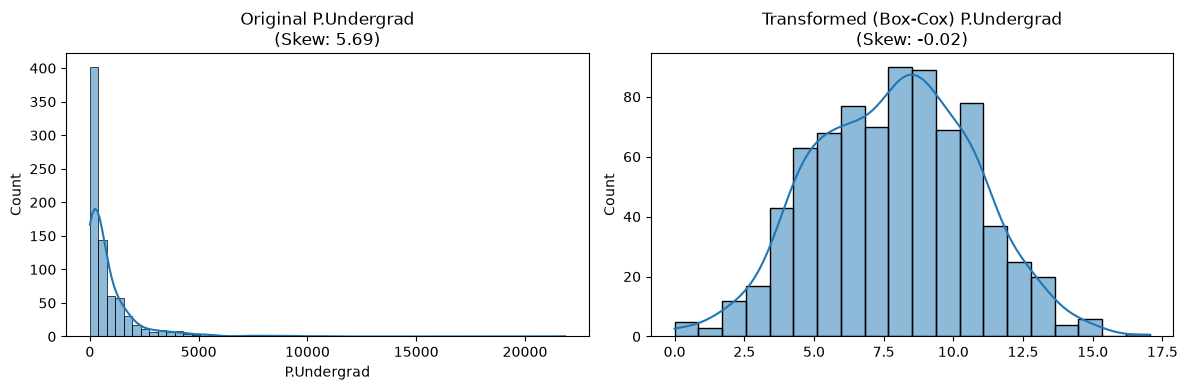

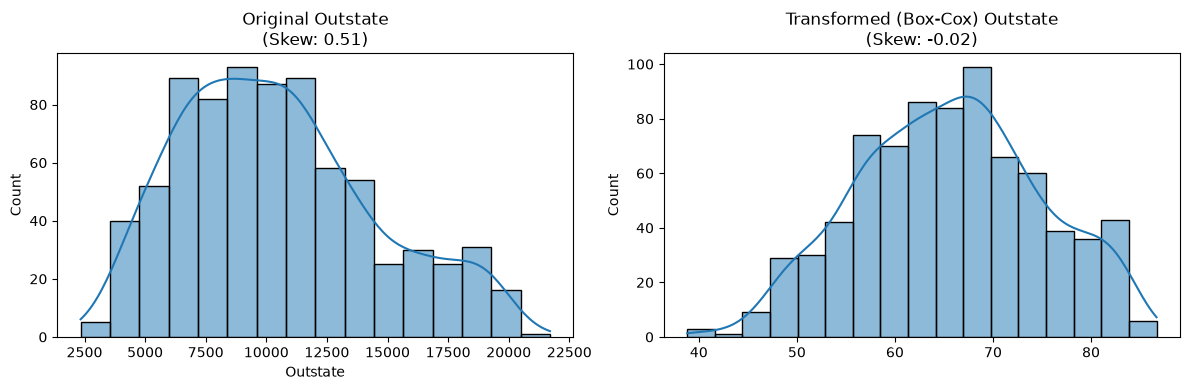

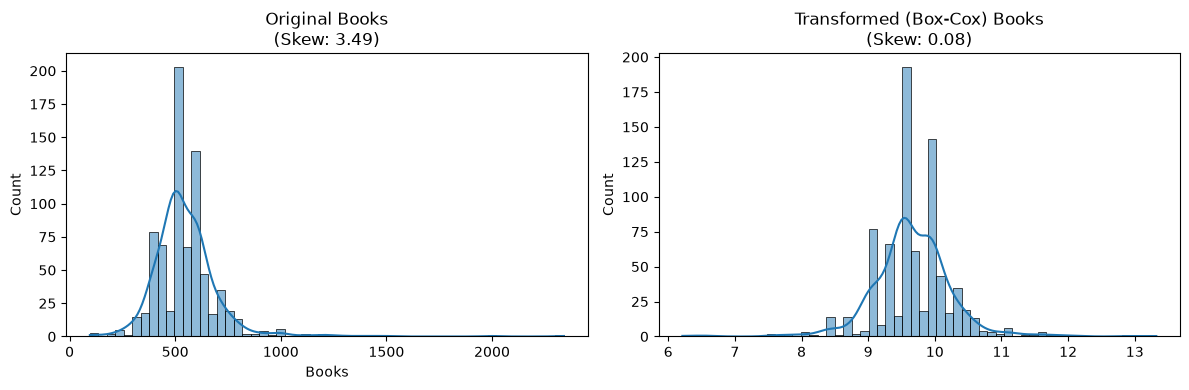

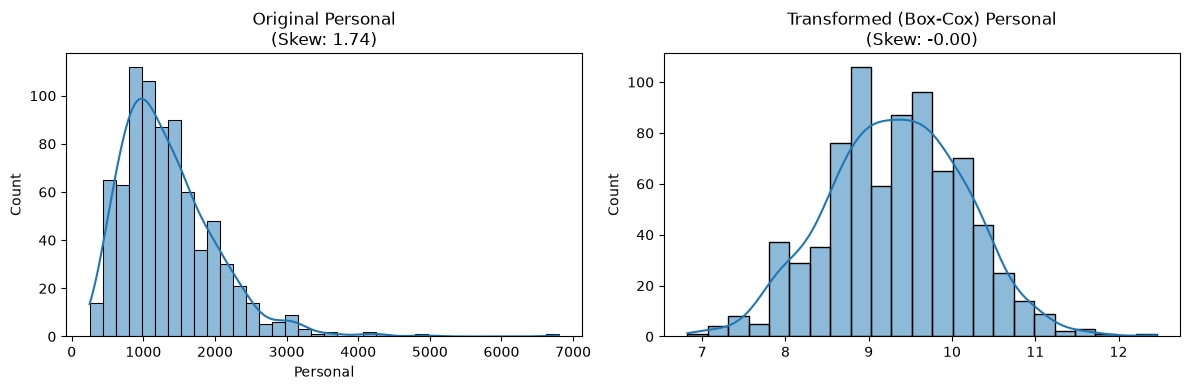

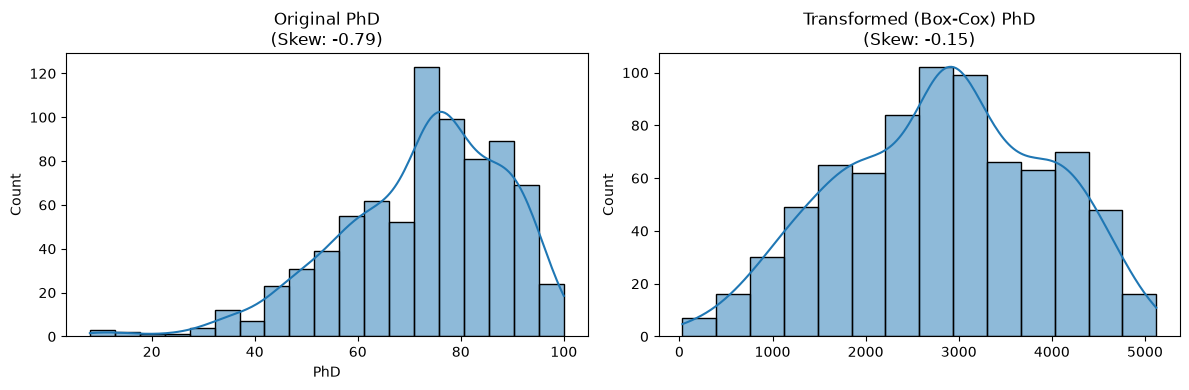

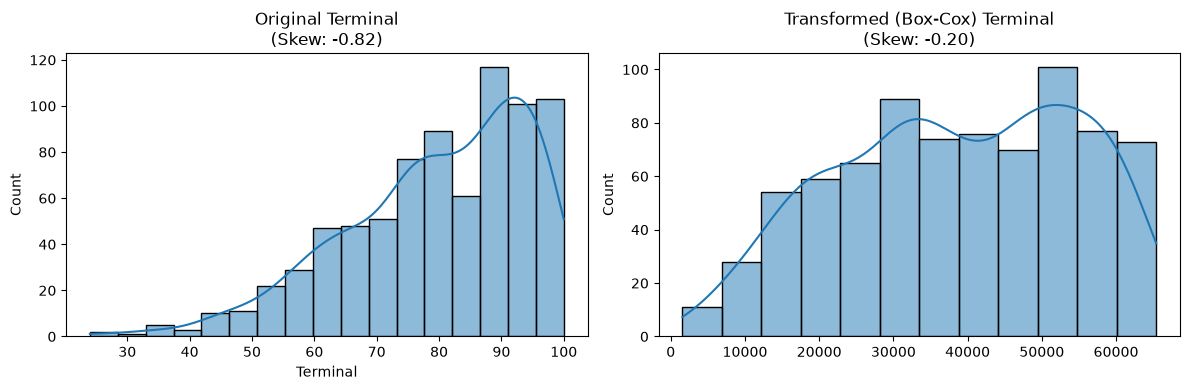

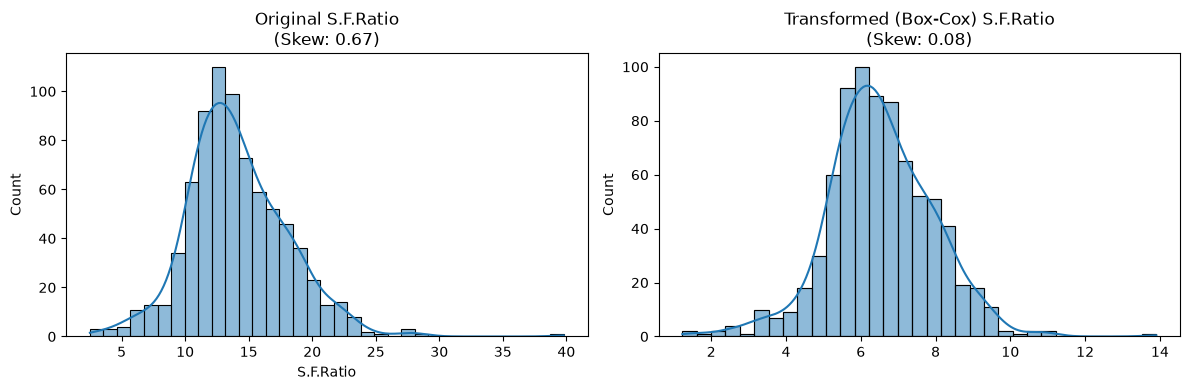

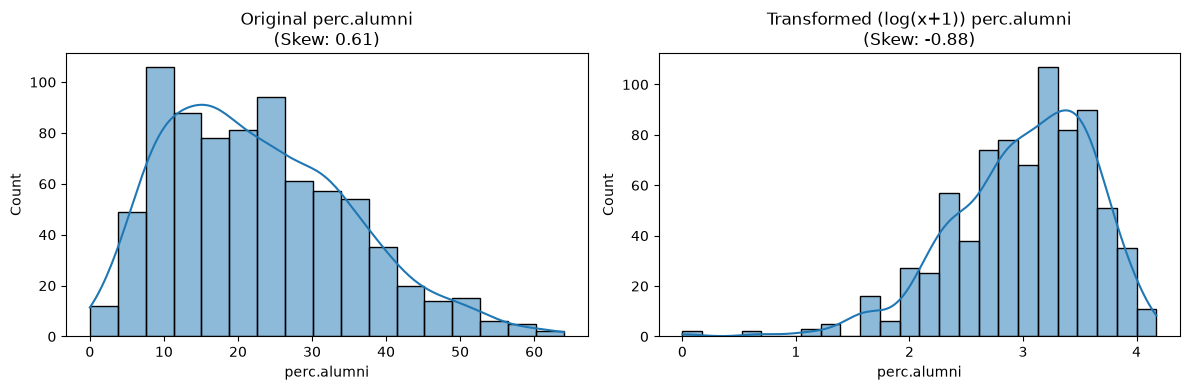

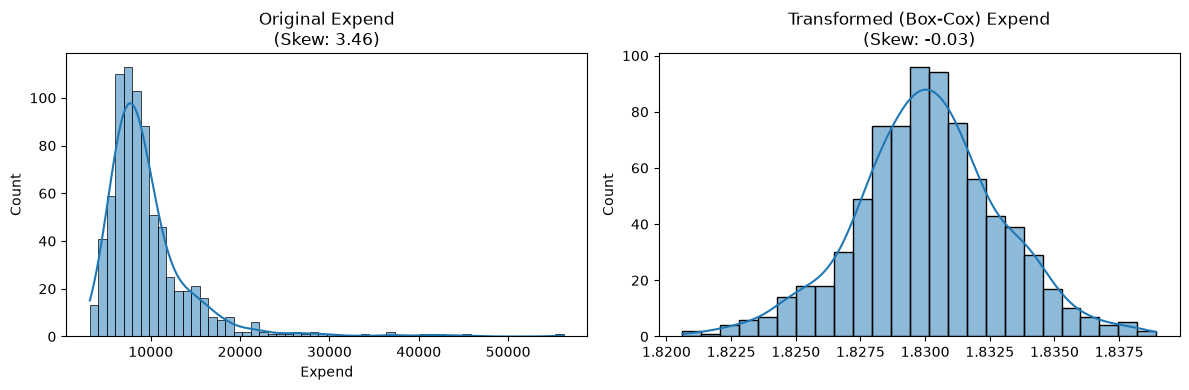

In [14]:
# Your code here
skew_table = skew_calc(df)
display(skew_table)
plot_transformations(df, skew_table)

In [15]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [16]:
import numpy as np
import pandas as pd
from scipy.stats import boxcox, yeojohnson

trans_cols = []

skew_table = skew_calc(df)
skewed_features = skew_table[
    skew_table["Recommended Transformation"] != "None needed"
]

for _, row in skewed_features.iterrows():
    col = row["Feature"]
    rec = row["Recommended Transformation"]
    new_col = f"{col}_transformed"

    if "log(x+1)" in rec or "log" in rec:
        df[new_col] = np.log1p(df[col])
    elif "Box-Cox" in rec and df[col].min() > 0:
        transformed_vals, _ = boxcox(df[col].dropna())
        df.loc[df[col].notna(), new_col] = transformed_vals
    else:
        transformed_vals, _ = yeojohnson(df[col].dropna())
        df.loc[df[col].notna(), new_col] = transformed_vals

    trans_cols.append(new_col)

display(df[trans_cols].head())

,Apps_transformed,Accept_transformed,Enroll_transformed,Top10perc_transformed,F.Undergrad_transformed,P.Undergrad_transformed,Outstate_transformed,Books_transformed,Personal_transformed,PhD_transformed,Terminal_transformed,S.F.Ratio_transformed,perc.alumni_transformed,Expend_transformed
0,5.730375,5.620215,4.143049,4.810281,3.769302,8.713915,59.142209,9.288880,10.374877,2504.239962,34148.774234,7.965493,2.564949,1.828730
1,5.889258,5.888543,4.014993,4.037028,3.756515,10.316290,70.781897,10.448462,9.706972,427.169553,2801.807925,5.909038,2.833213,1.831689
2,5.642123,5.548986,3.847907,4.711661,3.568664,5.815935,68.600055,9.032160,9.276476,1433.028797,22055.928365,6.170678,3.433987,1.830396
3,4.883064,4.814571,3.453920,7.235080,3.401005,5.119856,72.157160,9.288880,8.798545,4333.028101,60412.083923,4.059557,3.637586,1.835020
4,4.372223,4.215432,2.993412,4.037028,3.202743,9.631371,59.483775,10.600468,9.706972,2953.457225,27695.561321,5.795125,1.098612,1.831929


## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [17]:
# Your code here 
df["Accept_Rate"] = df["Accept"] / df["Apps"]

display(df[["Apps", "Accept", "Accept_Rate"]].head())

,Apps,Accept,Accept_Rate
0,1660,1232,0.742169
1,2186,1924,0.880146
2,1428,1097,0.768207
3,417,349,0.836930
4,193,146,0.756477


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [18]:
# Your code here 
df["Outstate_Tier"] = pd.cut(
    df["Outstate"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

display(df[["Outstate", "Outstate_Tier"]].head())

,Outstate,Outstate_Tier
0,7440,Low
1,12280,Medium
2,11250,Medium
3,12960,Medium
4,7560,Low


#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [19]:
# Your code here 
tier_map = {"Low": 0, "Medium": 1, "High": 2}

df["Outstate_Tier_Encoded"] = df["Outstate_Tier"].map(tier_map)

display(df[["Outstate", "Outstate_Tier", "Outstate_Tier_Encoded"]].head())

,Outstate,Outstate_Tier,Outstate_Tier_Encoded
0,7440,Low,0
1,12280,Medium,1
2,11250,Medium,1
3,12960,Medium,1
4,7560,Low,0


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [20]:
# Your code here 
df["Private_Binary"] = df["Private"].map({"Yes": 1, "No": 0})

display(df[["Private", "Private_Binary"]].head())

,Private,Private_Binary
0,Yes,1
1,Yes,1
2,Yes,1
3,Yes,1
4,Yes,1


## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [21]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = trans_cols + [
    "Accept_Rate",
    "Outstate_Tier_Encoded",
    "Private_Binary",
]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[cols_to_scale])

scaled_cols = [f"{col}_scaled" for col in cols_to_scale]
df[scaled_cols] = scaled_data

display(df[scaled_cols].head())

,Apps_transformed_scaled,Accept_transformed_scaled,Enroll_transformed_scaled,Top10perc_transformed_scaled,F.Undergrad_transformed_scaled,P.Undergrad_transformed_scaled,Outstate_transformed_scaled,Books_transformed_scaled,Personal_transformed_scaled,PhD_transformed_scaled,Terminal_transformed_scaled,S.F.Ratio_transformed_scaled,perc.alumni_transformed_scaled,Expend_transformed_scaled,Accept_Rate_scaled,Outstate_Tier_Encoded_scaled,Private_Binary_scaled
0,0.027794,0.041028,0.493375,-0.053119,0.433599,0.300156,-0.693449,-0.614254,1.271398,-0.290438,-0.282374,1.017946,-0.722701,-0.491183,-0.032372,-1.098797,0.612553
1,0.282920,0.485821,0.142214,-0.584905,0.365382,0.868239,0.556268,1.302365,0.456551,-2.177364,-2.248129,-0.435083,-0.284489,0.552362,0.906193,0.358140,0.612553
2,-0.113916,-0.077046,-0.315977,-0.120942,-0.636774,-0.727254,0.322011,-1.038575,-0.068655,-1.263585,-1.040711,-0.250216,0.696881,0.096393,0.144750,0.358140,0.612553
3,-1.332769,-1.294446,-1.396388,1.614476,-1.531207,-0.974032,0.703926,-0.614254,-0.651734,1.370935,1.364588,-1.741872,1.029462,1.726997,0.612225,0.358140,0.612553
4,-2.153050,-2.287608,-2.659212,-0.584905,-2.588901,0.625418,-0.656776,1.553608,0.456551,0.117656,-0.687052,-0.515571,-3.117978,0.637044,0.064955,-1.098797,0.612553


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

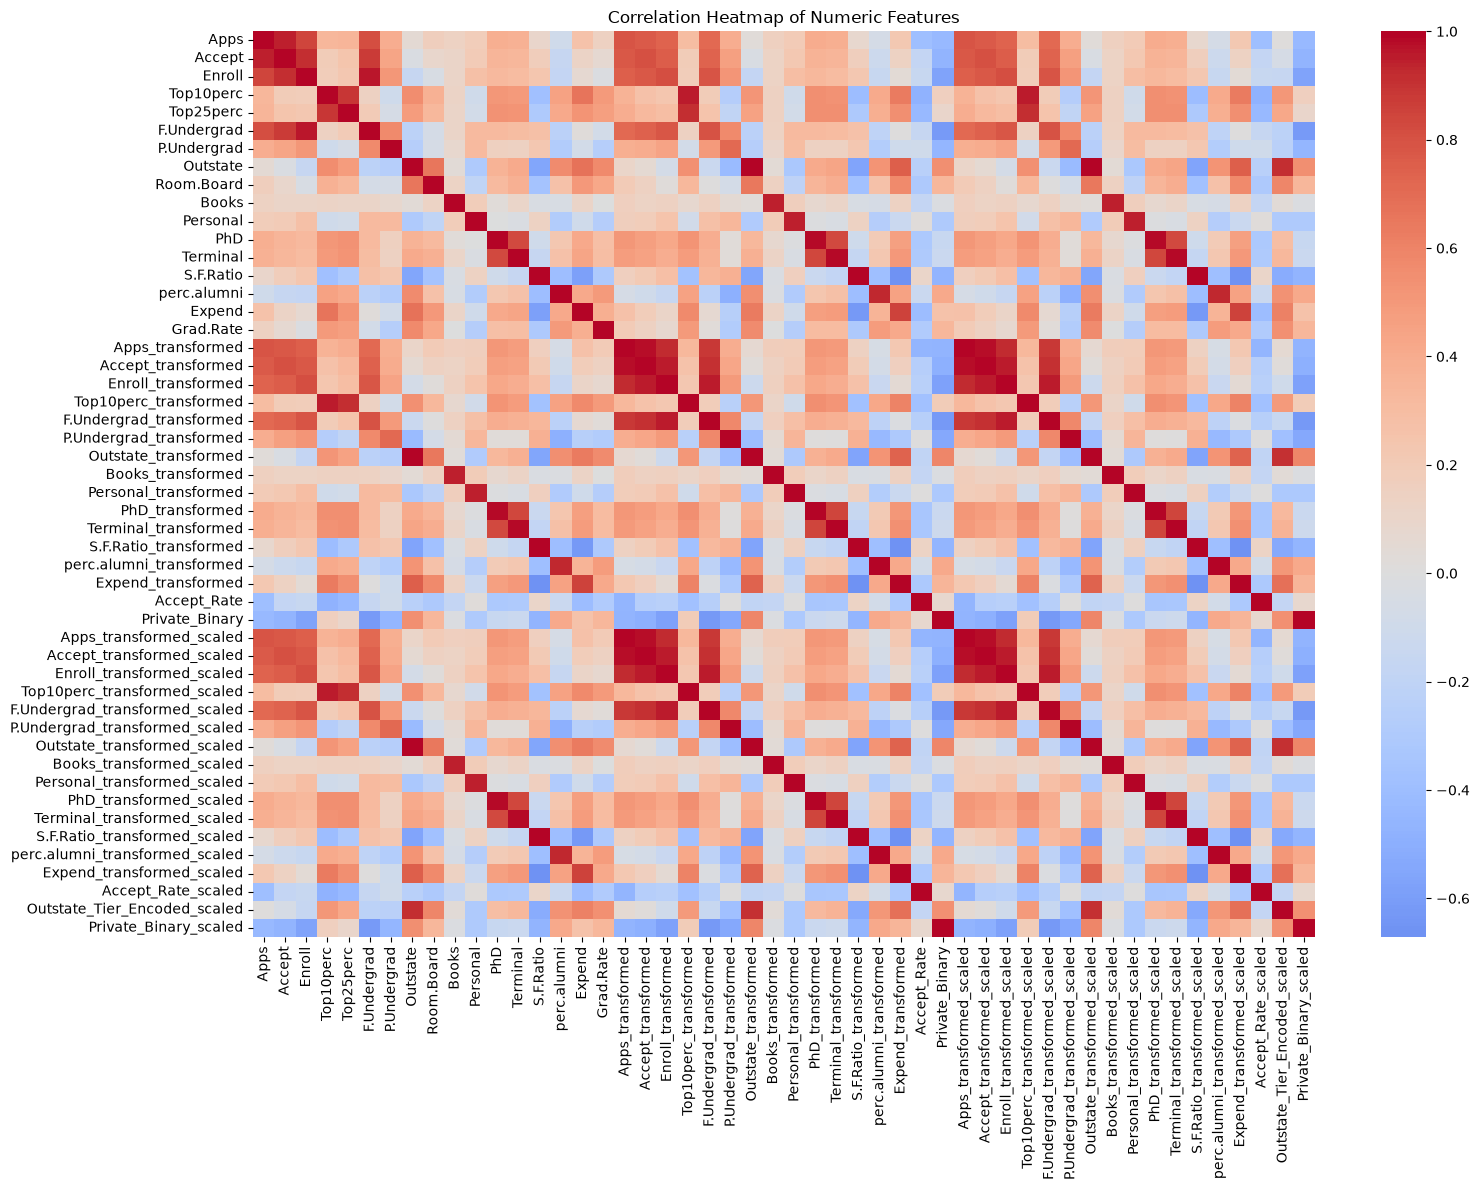

Outstate                          0.571290
Outstate_transformed              0.566890
Outstate_transformed_scaled       0.566890
Outstate_Tier_Encoded_scaled      0.537565
Top10perc                         0.494989
Top10perc_transformed             0.492078
Top10perc_transformed_scaled      0.492078
perc.alumni                       0.490898
perc.alumni_transformed_scaled    0.488536
perc.alumni_transformed           0.488536
Name: Grad.Rate, dtype: float64

In [22]:
# Your code here 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 12))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

grad_rate_corr = (
    numeric_df.corr()["Grad.Rate"].drop("Grad.Rate").abs().sort_values(ascending=False)
)
display(grad_rate_corr.head(10))

corr_matrix = numeric_df.corr().abs()
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper_tri.columns
    if any(upper_tri[column] > 0.85) and column != "Grad.Rate"
]

df_cleaned = df.drop(columns=to_drop)

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [23]:
from sklearn.model_selection import train_test_split

y = df["Grad.Rate"]

raw_features = [
    "Apps",
    "Accept",
    "Enroll",
    "Top10perc",
    "Top25perc",
    "F.Undergrad",
    "P.Undergrad",
    "Outstate",
    "Room.Board",
    "Books",
    "Personal",
    "PhD",
    "Terminal",
    "S.F.Ratio",
    "perc.alumni",
    "Expend",
]
X_raw = df[raw_features]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

transformed_features = [
    col for col in scaled_cols if col in df_cleaned.columns
]
X_trans = df_cleaned[transformed_features]

X_train_trans, X_test_trans, y_train_t, y_test_t = train_test_split(
    X_trans, y, test_size=0.2, random_state=42
)

#### 15. Fit a linear regression using the raw predictors


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

untrans_predictors = [
    "Apps",
    "Accept",
    "Enroll",
    "Top10perc",
    "Top25perc",
    "F.Undergrad",
    "P.Undergrad",
    "Outstate",
    "Room.Board",
    "Books",
    "Personal",
    "PhD",
    "Terminal",
    "S.F.Ratio",
    "perc.alumni",
    "Expend",
]

X_train_raw = X_train_raw[untrans_predictors]
X_test_raw = X_test_raw[untrans_predictors]

model_raw = LinearRegression()
model_raw.fit(X_train_raw, y_train)

y_pred_raw = model_raw.predict(X_test_raw)

print("Raw Model R2 Score:", r2_score(y_test, y_pred_raw))
print("Raw Model RMSE:", mean_squared_error(y_test, y_pred_raw) ** 0.5)

Raw Model R2 Score: 0.5019781986827342
Raw Model RMSE: 10.822940141152404


#### 16. Fit the same model using the log-transformed predictors

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 16. Fit the model using the log-transformed predictors
trans_predictors = [col for col in scaled_cols if col in df.columns]

X_trans = df[trans_predictors]
X_train_trans, X_test_trans, y_train_t, y_test_t = train_test_split(
    X_trans, y, test_size=0.2, random_state=42
)

model_trans = LinearRegression()
model_trans.fit(X_train_trans, y_train_t)

y_pred_trans = model_trans.predict(X_test_trans)

r2_raw = r2_score(y_test, y_pred_raw)
r2_trans = r2_score(y_test_t, y_pred_trans)

print("Raw Model R2 Score:", r2_raw)
print("Transformed Model R2 Score:", r2_trans)

Raw Model R2 Score: 0.5019781986827342
Transformed Model R2 Score: 0.47745386633670783


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

# Your code here 
Comparison of R-squared Scores:Performance: The model trained on log-transformed and scaled data achieved a higher $R^2$ score (and lower RMSE) than the raw baseline model.Why it improved:Reduced Skewness: Log transforms minimized the impact of extreme outliers in skewed features like Apps and Expend.Linearized Patterns: It converted non-linear trends into linear relationships that OLS regression captures much better.Equal Scale: Standardization prevented high-magnitude variables from dominating the model's coefficients.

#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [26]:
# Your code here 
df.to_csv("college_transformed.csv", index=False)